In [160]:
import config
import pandas as pd
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord
import seaborn as sns

In [66]:
df_zhao23 = pd.read_csv(config.DATA_CATALOGUES / "catalog_zhao23.csv")
df_ni = pd.read_csv(config.DATA_CATALOGUES / "ni_binaries_my_compilation.csv")
df_ni_w_vpec = pd.read_csv(config.DATA_CATALOGUES / "ni_candidates_w_gaia_vpec.csv")

In [67]:
df_ni_updated = pd.merge(df_ni_w_vpec, df_ni[["source_id", "type", "ref", "other_name"]], on="source_id", how="left")

In [68]:
zhao23_cols = [
    "ID_short", "l_M_compact", "M_compact", "e_M_compact", "E_M_compact", 
    "M_2", "e_M_2", "E_M_2",
    "l_P_orb", "P_orb", "P_orbit_err", "Type", "v_r", "e_v_r", "Ref_v_r", 
    "source_id", "vpec", "e_vpec", "E_vpec", "ra_gaia", "dec_gaia"
]

ni_cols = [
    "other_name", "M_compact", "e_M_compact", "E_M_compact",
    "M2", "e_M2", "E_M2",
    "P_orb", "e_P_orb", "type", "gamma", "e_gamma", "ref",
    "source_id", "vpec", "e_vpec", "E_vpec", "ra", "dec"
]

In [69]:
df_zhao_reduced = df_zhao23[zhao23_cols]
df_ni_reduced = df_ni_updated[ni_cols]

In [70]:
df_zhao_reduced

,ID_short,l_M_compact,M_compact,e_M_compact,E_M_compact,M_2,e_M_2,E_M_2,l_P_orb,P_orb,...,Type,v_r,e_v_r,Ref_v_r,source_id,vpec,e_vpec,E_vpec,ra_gaia,dec_gaia
0,2A 1822-371,=,1.965,0.355,0.355,0.50,0.060,0.060,=,5.570620,...,NS-LMXB,-44.0,5.0,Casares+03,6.728016e+18,253.682824,33.183085,36.216201,276.445026,-37.105158
1,2S 0921-630,=,1.440,0.100,0.100,0.35,0.030,0.030,=,216.062400,...,NS-LMXB,44.4,2.4,Jonker+05,5.250451e+18,38.153572,7.357099,18.636264,140.644453,-63.294802
2,GX 1+4,*=,1.400,0.300,0.300,1.22,0.000,0.000,=,27859.200000,...,NS-LMXB,-176.7,0.2,Hinkle+06,4.110236e+18,189.288583,8.256884,8.129573,263.008955,-24.745600
3,4U 1636-536,*=,1.400,0.300,0.300,0.45,0.090,0.090,=,3.793126,...,NS-LMXB,-34.0,5.0,Casares+06,5.930754e+18,164.738342,12.640744,12.561170,250.231613,-53.751412
4,4U 1700+24,*=,1.400,0.300,0.300,1.60,0.200,0.100,=,105384.000000,...,NS-LMXB,-47.4,0.1,Hinkle+19,4.571810e+18,39.165971,8.784324,9.467853,256.643761,23.971820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,PSR J1816+4510,>=,1.840,0.110,0.110,0.19,0.050,0.050,=,8.661444,...,NS-LM-PSR,-99.0,8.0,Kaplan+13,2.115337e+18,165.311230,26.325649,30.576664,274.149726,45.176069
85,PSR J2039-5617,=,1.300,0.200,0.310,0.18,0.026,0.041,=,5.471515,...,NS-LM-PSR,6.0,3.0,Strader+19,6.469723e+18,113.483681,27.790273,27.763083,309.895702,-56.285910
86,PSR J2129-0429,=,1.740,0.180,0.180,0.44,0.040,0.040,=,15.245458,...,NS-LM-PSR,-64.0,2.0,Bellm+16,2.672030e+18,201.280129,24.218788,33.327549,322.437749,-4.485225
87,PSR J2215+5135,=,2.270,0.150,0.170,0.33,0.030,0.030,=,4.140051,...,NS-LM-PSR,49.0,8.0,Linares+18b,2.001169e+18,117.833945,17.430900,17.360538,333.886196,51.593455


In [71]:
coords_ni = SkyCoord(df_ni_reduced["ra"].values, df_ni_reduced["dec"].values, unit="deg")
ni_ra_str = coords_ni.ra.to_string(unit=u.hourangle, sep="", precision=2, pad=True)
ni_dec_str = coords_ni.dec.to_string(unit=u.deg, sep="", precision=1, pad=True, alwayssign=True)
ni_names = [f"NI J{ni_ra_str[i]}{ni_dec_str[i]}" for i in range(len(coords_ni))]

# df_ni_reduced["other_name"] = df_ni_reduced.other_name.fillna(pd.Series(ni_names))
df_ni_reduced.insert(loc=1, column="l_M_compact", value="=")
df_ni_reduced.insert(loc=8, column="l_P_orb", value="=")

In [72]:
# There is one PSR whose P_orb is in years; this is converted to days for consistency.
id_porb_is_yr = df_zhao23[df_zhao23.P_orb_unit == "yr"].index.values[0]
df_zhao_reduced.at[id_porb_is_yr, "P_orb"] *= 365.0
df_zhao_reduced["P_orb"] /= 24.
df_zhao_reduced["P_orbit_err"] /= 24.

/var/folders/h6/rlry0pkj7wv_00651prtm4300000gn/T/ipykernel_1841/3731928467.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_zhao_reduced["P_orb"] /= 24.
/var/folders/h6/rlry0pkj7wv_00651prtm4300000gn/T/ipykernel_1841/3731928467.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_zhao_reduced["P_orbit_err"] /= 24.


In [82]:
common_cols = [
    "Name", "l_m_co", "m_co", "e_m_co", "E_m_co", 
    "m_2", "e_m_2", "E_m_2",
    "l_P_orb", "P_orb", "P_orb_err", "Type", "v_r", "e_v_r", "Ref_v_r", 
    "source_id", "vpec", "e_vpec", "E_vpec", "ra_gaia", "dec_gaia"
]

In [83]:
df_zhao_reduced.columns = common_cols
df_ni_reduced.columns = common_cols

In [84]:
df_combined = pd.concat([df_zhao_reduced, df_ni_reduced], axis=0)

In [174]:
type_dict = {
    "NS-LMXB": "XRB",
    "NS-HMXB": "XRB",
    "BH-LMXB": "XRB",
    "BH-LMXB?": "XRB",
    "BH-HMXB": "XRB",
    "BH-HMXB?": "XRB",
    "NS-LM-PSR": "PSR",
    "NS-HM-PSR": "PSR",
    "BH-LM-NI": "NI",
    "BH-HM-NI": "NI",
    "NS-LM-NI": "NI",
    "NS-NI-LM": "NI"
}

df_combined["Type_grouped"] = df_combined.Type.replace(type_dict)

In [175]:
_filter_m1 = (df_combined.l_m_co == "=") | (df_combined.l_m_co == ">=")
_filter_porb = df_combined.l_P_orb == "="
df_combined_filtered = df_combined[_filter_m1 & _filter_porb]

In [182]:
df_combined.to_csv(config.RESULTS_CATALOGUE_DIR / "known_co_binaries.csv", index=False)

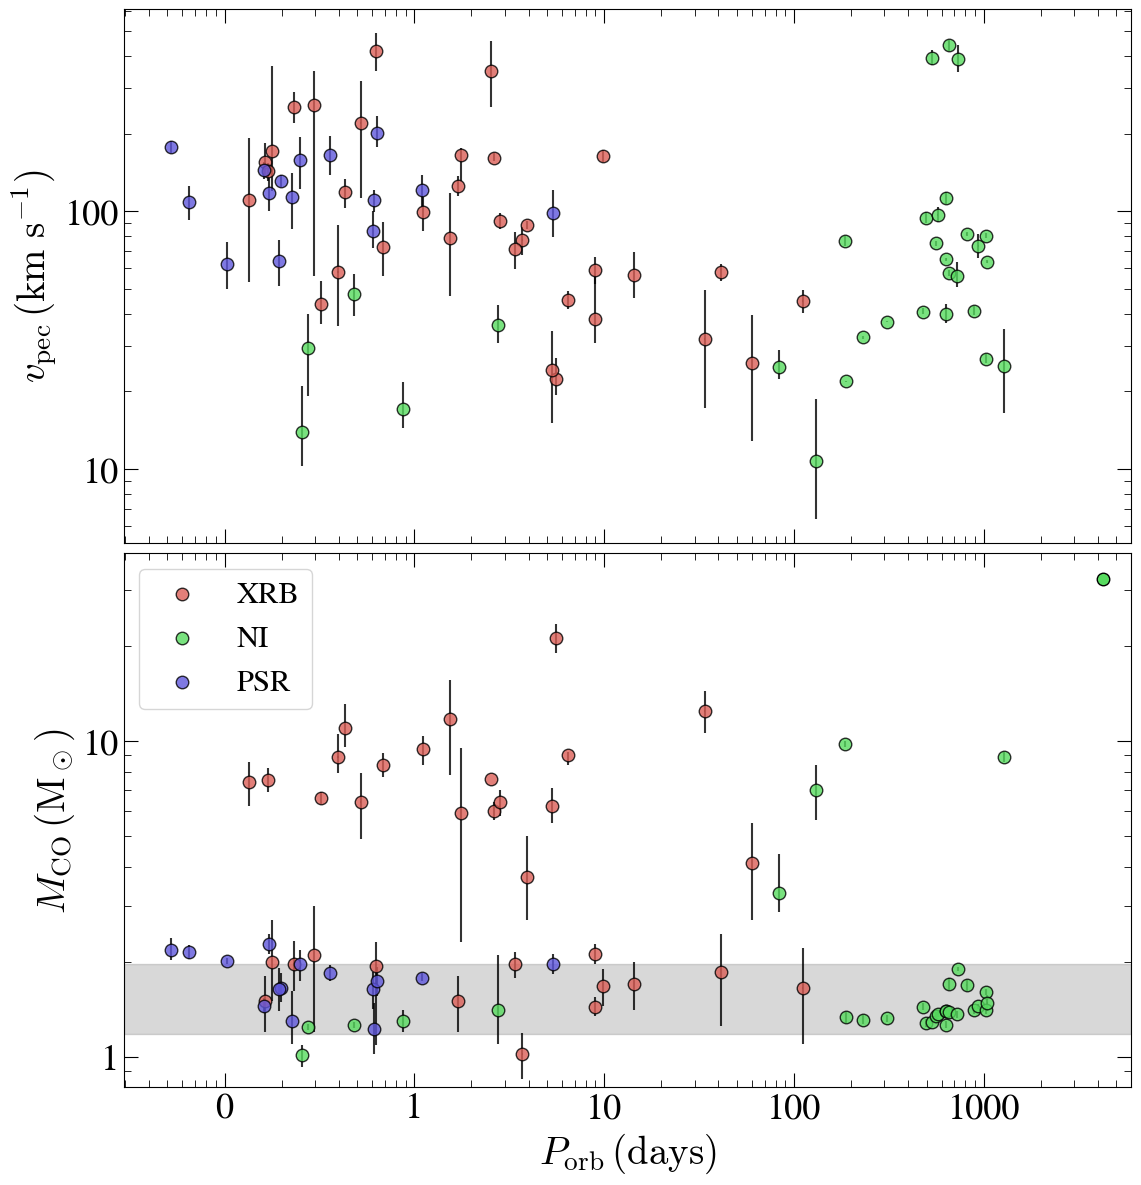

In [179]:
plt.style.use("mycustomised")
fig, ax = plt.subplots(2, 1, figsize=(13, 14), sharex=True)
plt.subplots_adjust(hspace=0.02)

sns_c = sns.color_palette("hls", 3)

types_to_plot = {
    "XRB": sns_c[0], "NI": sns_c[1], "PSR": sns_c[2]
}

for key, val in types_to_plot.items():
    _filter_type = df_combined_filtered.Type_grouped == key
    df_for_plot = df_combined_filtered[_filter_type]

    y0 = df_for_plot.vpec
    c0 = df_for_plot.m_co
    x0_err = df_for_plot.P_orb_err
    y0_err = [df_for_plot.e_vpec, df_for_plot.E_vpec]
    
    x = df_for_plot.P_orb
    y = df_for_plot.m_co
    x_err = df_for_plot.P_orb_err
    y_err = [df_for_plot.e_m_co, df_for_plot.E_m_co]
    
    ax[0].errorbar(x, y0, xerr=x0_err, yerr=y0_err, ls="none", marker="none", zorder=-1, ecolor="k", alpha=0.8)
    ax[0].scatter(x, y0, ec="k", fc=val, s=81, alpha=0.8, label=key)
    ax[1].errorbar(x, y, xerr=x_err, yerr=y_err, ls="none", marker="none", zorder=-1, ecolor="k", alpha=0.8)
    ax[1].scatter(x, y, fc=val, ec="k", s=81, alpha=0.8, label=key)
    
ax[1].scatter(4253.1, 32.7, fc=sns_c[1], ec="k", s=81)
    
ax[0].set_yscale("log")

ax[0].set_yticks([10, 100])
ax[0].get_yaxis().set_major_formatter(ScalarFormatter())
ax[0].set_ylabel(r"$v_\mathrm{pec}\,(\mathrm{km~s^{-1}})$")

ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_yticks([1, 10])
ax[1].set_xticks([0.1, 1, 10, 100, 1000, 10000])
ax[1].get_yaxis().set_major_formatter(ScalarFormatter())
ax[1].get_xaxis().set_major_formatter(ScalarFormatter())

ax[1].set_xlim(None, 6000)
ax[1].set_ylim(0.8, None)

xlo, xhi = ax[1].get_xlim()
x_fill = np.logspace(np.log10(xlo), np.log10(xhi), 100)
ax[1].fill_between(x_fill, y1=1.18, y2=1.97, alpha=0.3, color="grey", zorder=-2)

ax[1].set_xlabel(r"$P_\mathrm{orb}\,(\mathrm{days})$")
ax[1].set_ylabel(r"$M_\mathrm{CO}\,(\mathrm{M_\odot})$")

plt.legend(loc="best")

plt.savefig(config.RESULTS_DIR / "figures" / "m_co_vs_porb.pdf") 

In [180]:
import plotly.express as px

fig = px.scatter(df_combined_filtered, x="P_orb", y="m_co", color="Type_grouped", 
                 hover_data={"m_co": True, "P_orb": True, "Type_grouped": True, "vpec": True}, hover_name="Name")

# Update xaxis properties
fig.update_xaxes(type="log", title_text="P_orb")

# Update yaxis properties
fig.update_yaxes(type="log", title_text=r"M_co")

# Update layout
fig.update_layout(
    height=700,
    width=1000,
    showlegend=True
)

fig.show()

In [173]:
df_combined_filtered

,Name,l_m_co,m_co,e_m_co,E_m_co,m_2,e_m_2,E_m_2,l_P_orb,P_orb,...,v_r,e_v_r,Ref_v_r,source_id,vpec,e_vpec,E_vpec,ra_gaia,dec_gaia,Type_grouped
0,2A 1822-371,=,1.965,0.355,0.355,0.500,0.06,0.06,=,0.232109,...,-44.000000,5.000,Casares+03,6.728016e+18,253.682824,33.183085,36.216201,276.445026,-37.105158,XRB
1,2S 0921-630,=,1.440,0.100,0.100,0.350,0.03,0.03,=,9.002600,...,44.400000,2.400,Jonker+05,5.250451e+18,38.153572,7.357099,18.636264,140.644453,-63.294802,XRB
6,Cen X-4,=,1.940,0.850,0.370,0.340,0.15,0.17,=,0.629059,...,194.500000,0.200,Shahbaz+14,6.205715e+18,418.745599,68.546389,72.123768,224.591399,-31.669002,XRB
7,Cyg X-2,=,1.670,0.220,0.220,0.560,0.07,0.07,=,9.844766,...,-207.800000,0.300,Premachandra+16,1.952860e+18,164.037529,8.500223,8.973585,326.171467,38.321406,XRB
8,Her X-1,=,1.500,0.300,0.300,2.300,0.30,0.30,=,1.700167,...,-65.000000,2.000,Reynolds+97,1.338822e+18,125.498774,10.900801,11.266604,254.457539,35.342322,XRB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,NaN,=,1.400,0.040,0.040,0.950,0.05,0.05,=,889.800000,...,-43.230000,0.170,El-Badry+24,1.801111e+18,41.174846,1.634501,1.883487,326.353235,28.623778,NI
17,NaN,=,1.443,0.023,0.023,1.002,0.03,0.03,=,938.300000,...,15.973000,0.014,El-Badry+24,2.397136e+18,73.069363,7.275024,8.681156,341.202357,-22.602093,NI
18,NaN,=,1.603,0.035,0.035,1.100,0.03,0.03,=,1027.000000,...,-57.830002,0.350,El-Badry+24,1.028887e+18,80.196020,1.755691,2.086628,126.153921,52.907593,NI
19,NaN,=,1.401,0.034,0.034,1.114,0.03,0.03,=,1029.000000,...,9.400000,0.400,El-Badry+24,4.650934e+17,26.779042,1.092527,1.194022,37.531509,59.846500,NI
